In [17]:
import numpy as np

# 오차역전파법

* 신경망의 가중치 매개변수의 기울기(손실 함수의 기울기)는 수치 미분을 사용해 구했습니다.
* 수치 미분은 단순하고 구현하기도 쉽지만 계산 시간이 오래 걸린다는 큰 단점이 있습니다.
* 5장에서는 가중치 매개변수의 기울기를 효율적으로 계산하는 오차역전파(backpropagation)를 공부하겠습니다.

## 오차역전파법
* 제대로 이해하는 방법은 두 가지 존재 
1. 하나는 수식을 통한 것이고 
2. 다른 하나는 계산 그래프로 이해한다는 것 
    > 이 책은 계산 그래프를 사용해서 시각적으로 설명 

### 계산 그래프
* 계산 그래프는 계산 과정을 그래프로 나타낸 것입니다. 
* 여기에서의 그래프는 우리가 잘 아는 그래프 자료구조로 복수의 노드와 에지로 표현

* 문제 1 : 현빈 군은 슈퍼에서 1개에 100원인 사과를 2개 샀습니다. 이때 지불 금액을 구하세요. 단 소비세가 10% 부과됩니다. 

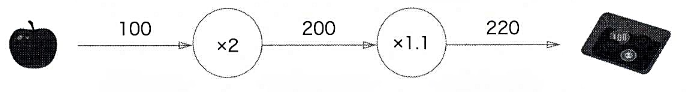

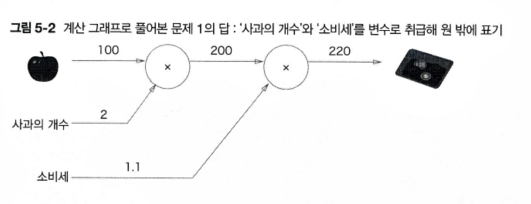

* 문제 2 : 현빈 군은 슈퍼에서 사과를 2개, 귤을 3개 샀습니다. 사과는 1개에 100원, 귤은 1개 150원입니다. 소비세가 10%일 때 지불 금액을 구하세요

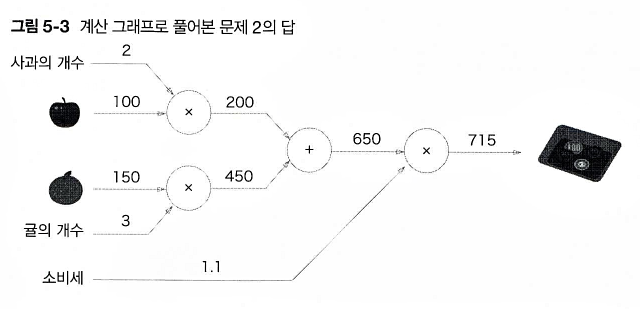

* 그래프를 이용한 문제풀이는 다음 흐름으로 진행
1. 계산 그래프를 구성
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 진행

#### 계산을 왼쪽에서 오른쪽으로 진행하는 단계를 순전파(forward propagation)이라고 합니다.
#### 순전파라는 이름이 있다면 반대 방향은 역전파(backpropagation)이라고 합니다.

## 국소적 계산 
* 국소적이란 자신과 직접 관계된 작은 범위라는 뜻
* 국소적 계산은 결국 전체에서 어떤 일이 벌어지든 상관없이 자신과 관계된 정보만으로 다음 결과를 출력

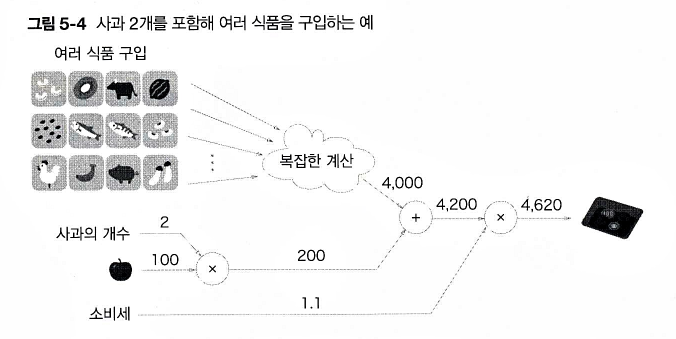

* 위의 그림에서 복잡한 계산에 관계없이 사과는 단지 계산된 4000원하고 더하면 된다 
* 다시 말하면 각 노드는 자신과 관련한 계산이외는 아무것도 신경 쓸 게 없다
* 계산이 아무리 복잡하더라도 각 단계에서 하는 일은 해당 노드에 국한된 국소적 계산입니다.

### 왜 계산 그래프로 푸는가?
* 계산 그래프를 사용하면 방금 설명한 국소적 계산이 가능
* 전체가 아무리 복잡해도 각 노드에서는 단순한 계산에 집중하여 문제를 단순화할 수 있습니다. 
* 계산 그래프는 중간 계산 결과를 모두 보관할 수 있습니다. 

#### 가장 큰 이유는 역전파를 통해 미분을 효율적으로 계산할 수 있다는 점

* 문제 1은 사과를 2개 사서 소비세를 포함한 최종 금액을 구하는 것 
* 여기서 가령 사과 가격이 오르면 최종 금액에 어떤 영향을 미치는지 알고 싶다고 합시다.
* 이는 사과 가격에 대한 지불 금액의 미분을 구하는 문제에 해당 
* 이 미분 값은 사과 값이 아주 조금 올랐을 때 지불 금액이 얼마나 증가하느냐를 표시 

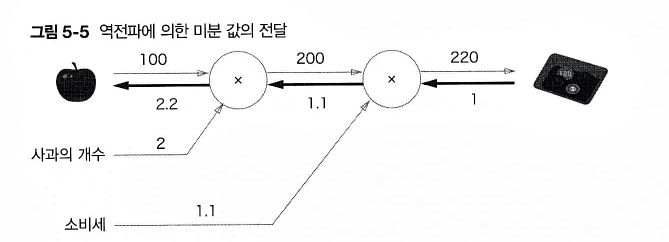

In [18]:
101 * 2 * 1.1

222.20000000000002

* 역전파는 순전파와는 반대 방향의 화살표로 그립니다. 
* 이 전파는 국소적 미분을 전달하고 그 미분 값은 화살표 아래에 적습니다.
* 이 예에서 역전파는 오른쪽에서 왼쪽으로 1 -> 1.1 -> 2.2순으로 미분 값을 전달합니다.
* 이 결과로부터 '사과 가격에 대한 지불 금액의 미분' 값은 2.2라 할 수 있습니다. 
* 사과가 1원 오르면 최종 금액은 2.2원 오른다는 의미입니다. 
* 정확히는 사과 값이 아주 조금 오르면 최종 금액은 그 아주 작은 값의 2.2배만큼 오른다는 뜻입니다. 
------
* 여기서는 사과 가격에 대한 미분만 구했지만, '소비세에 대한 지불 금액의 미분'이나 '사과 개수에 대한 지불 금액의 미분'도 같은 순서로 구할 수 있습니다. 
* 그리고 그때는 중간까지 구한 미분 결과를 공유할 수 있어서 다수의 미분을 효율적으로 계산할 수 있습니다. 
* 이처럼 계산 그래프의 이점은 순전파와 역전파를 활용해서 각 변수의 미분을 효율적으로 구할 수 있다는 점입니다. 

## 연쇄법칙
* 역전파는 국소적인 미분을 순방향과는 반대인 오른쪽에서 왼쪽으로 전달 
* 또한 이 국소적 미분을 전달하는 원리는 연쇄법칙(chain rule)에 따른 것입니다. 
* 연쇄법칙을 설명하고 그것이 계산 그래프 상의 역전파와 같다는 사실을 확인해보겠습니다. 

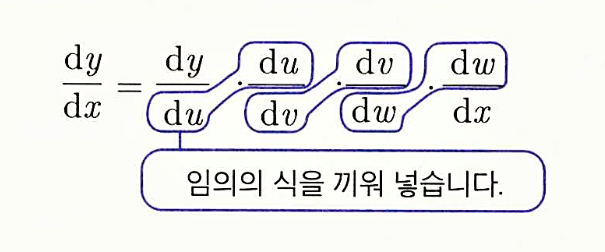

#### 연쇄법칙 간단한 문제 풀어보기 

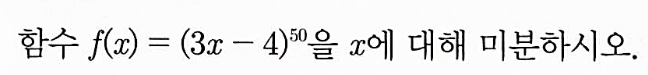

---------------

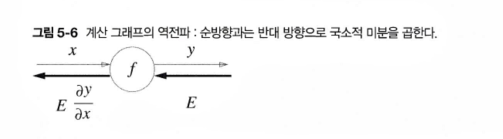

### 합성함수란 여러 함수로 구성된 함수
* $ z = (x + y)^2 $

* 합성 함수의 미분은 합성 함수를 구성하는 각 함수의 미분의 곱으로 나타낼 수 있습니다.
* 이것이 연쇄법칙의 원리 

## 계산 그래프 

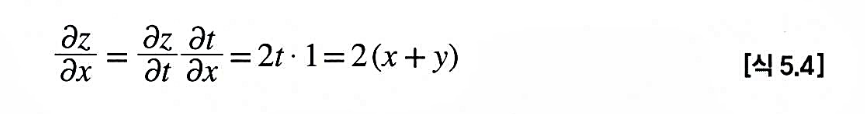

* 제곱승을 **2 노드로 표현

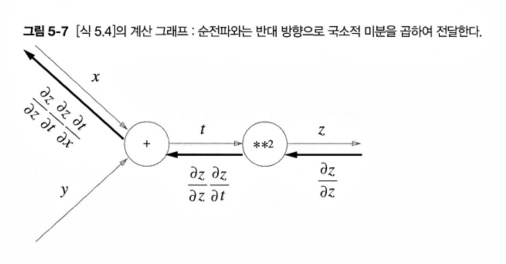

* **2 노드에서의 역전파를 살펴보겠습니다. 
* 입력은 $ \frac{\partial z }{\partial z}  $ 이며, 이에 국소적 미분은 $ \frac{\partial z }{\partial t} $

#### 연쇄법칙에 따르면... 
* $ \frac{\partial z }{\partial z}  $ $ \frac{\partial z }{\partial t}  $ $ \frac{\partial t }{\partial x}  $ = $ \frac{\partial z }{\partial t}  $ $ \frac{\partial t }{\partial x}  $ = $ \frac{\partial z }{\partial x}  $

* x에 대한 z의 미분이 됩니다. 즉, 역전파가 하는 일은 연쇄법칙의 원리와 같다는 것입니다. 

# 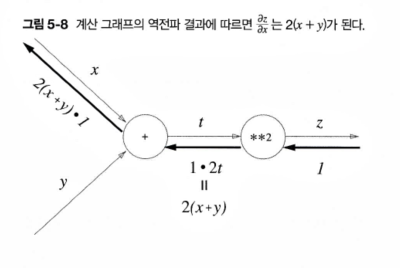

## 역전파
* 이번에는 '+'와 'x' 등의 연산을 예로 들어 역전파의 구조를 설명하겠습니다.

### 덧셈 노드의 역전파

* z = x + y의 미분은 다음과 같이 해석적으로 계산할 수 있습니다.

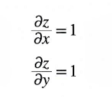

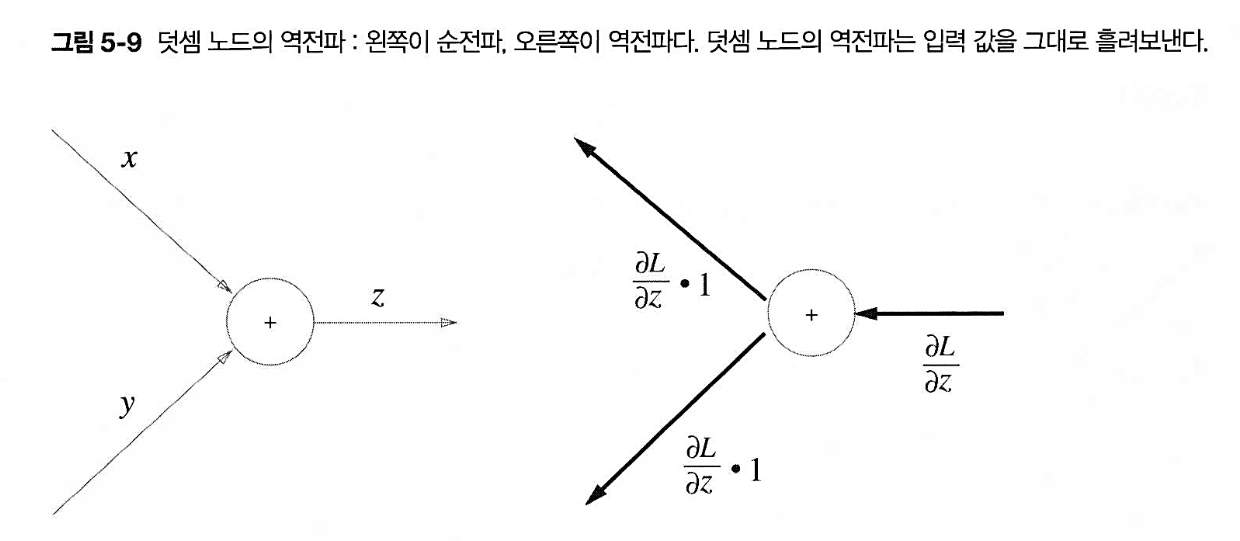
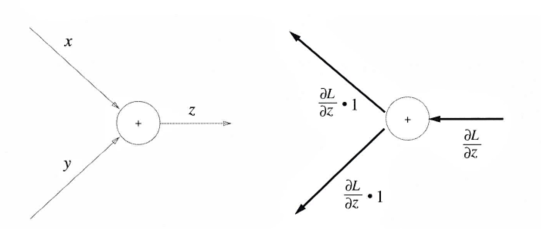

* 역전파 때는 상류에서 전해진 미분에 1을 곱하여 하류로 흘립니다.
* 즉 덧셈 노드의 역전파는 1을 곱하기만 할 뿐이므로 입력된 값을 그대로 다음 노드로 보내게 됩니다. 

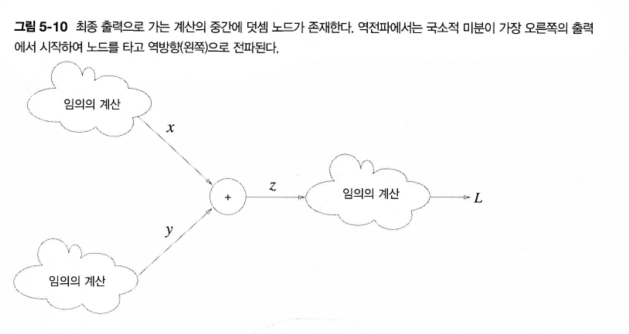

* 구체적인 예를 들어보면 가령 10 + 5 = 15라는 계산이 있고, 상류에는 1.3이라는 값이 흘러옵니다. 
* 이를 계산 그래프로 그리면 그림 5-11처럼 됩니다. 

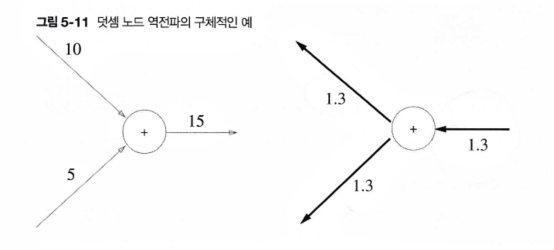

### 곱셈 노드의 역전파

* z = xy라는 식을 생각해보죠

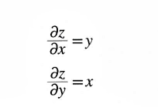

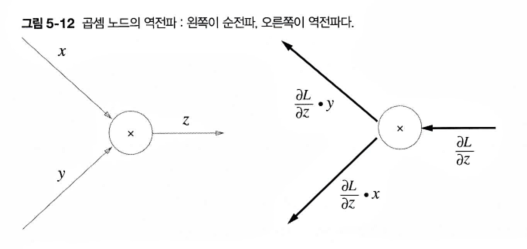

* 곱셈 노드 역전파는 상류의 값에 순전파 때의 입력 신호들을 '서로 바꾼 값'을 곱해서 하류로 보냅니다.
* 서로 바꾼 값이란 위의 그림에서 처럼 순전파 x였다면 역전파는 y, 순전파 때 y였다면 역전파에서는 x로 바꾼다는 의미입니다. 

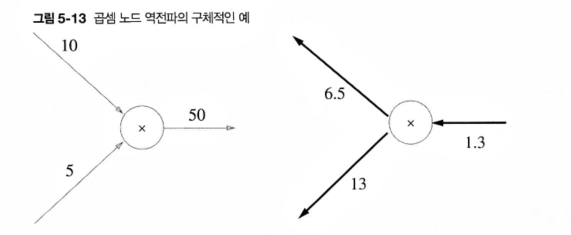

* 곱셈의 역전파는 순방향 입력 신호의 값이 필요합니다. 
* 그래서 곱셈 노드를 구현할 때는 순전파의 입력 신호를 유지합니다.

### 사과 쇼핑의 예
* 사과의 가격, 사과의 개수, 소비세라는 세 변수 각각이 최종 금액에 어떻게 영향을 주느냐를 풀고자 합니다. 
* 이는 사과 가격에 대한 지불 금액의 미분, 사과 개수에 대한 지불 금액의 미분, 소비세에 대한 지불 금액의 미분을 구하는 것에 해당합니다. 
* 이를 계산 그래프의 역전파를 사용해서 풀면 아래 그림처럼 됩니다. 

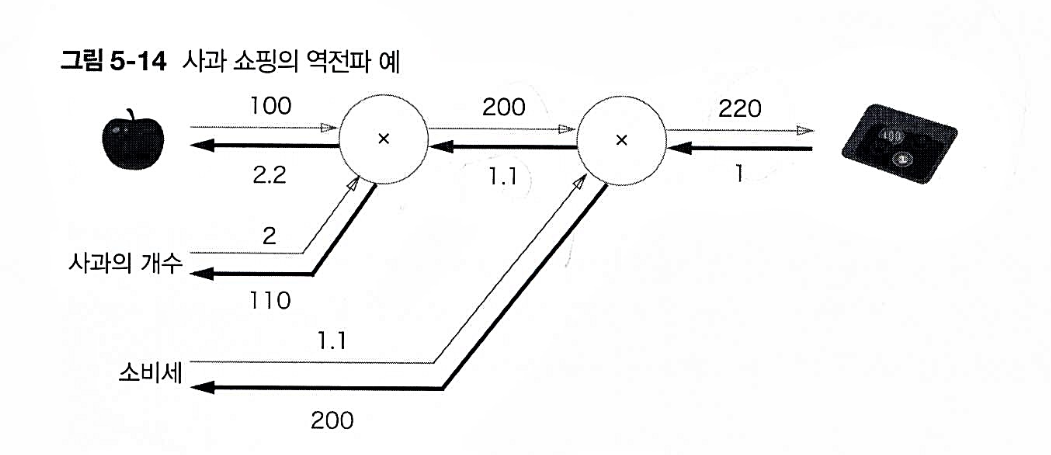

* 사과 가격의 미분은 2.2, 사과 개수의 미분은 110, 소비세의 미분은 200입니다. 
* 이는 소비세와 사과 가격이 같은 양만큼 오르면 최종 금액에는 소비세가 200의 크기로, 사과 가격이 2.2 크기로 영향을 준다고 해석할 수 있습니다. 
* 단 이 예시에서는 소비세와 사과 가격은 단위가 다르니 주의해야 합니다. (소비세 1은 100%를 의미하고, 사과 가격 1은 1원을 의미합니다.)

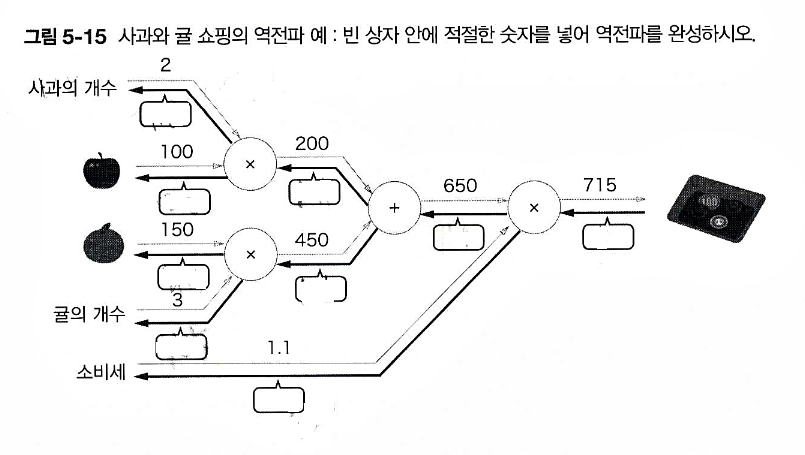

0.1

In [39]:
# 2.718281828459045
for x in range(10)[1:]:
    x = 0.1 ** x
    print ( "{} -> {}".format(x,  (1 + x) ** (1/x)) )

0.1 -> 2.5937424601000023
0.010000000000000002 -> 2.704813829421528
0.0010000000000000002 -> 2.7169239322355927
0.00010000000000000002 -> 2.718145926824925
1.0000000000000003e-05 -> 2.7182682371922966
1.0000000000000004e-06 -> 2.7182804690957525
1.0000000000000004e-07 -> 2.7182816941320804
1.0000000000000005e-08 -> 2.7182817983473564
1.0000000000000005e-09 -> 2.718282052011559


### 자연상수

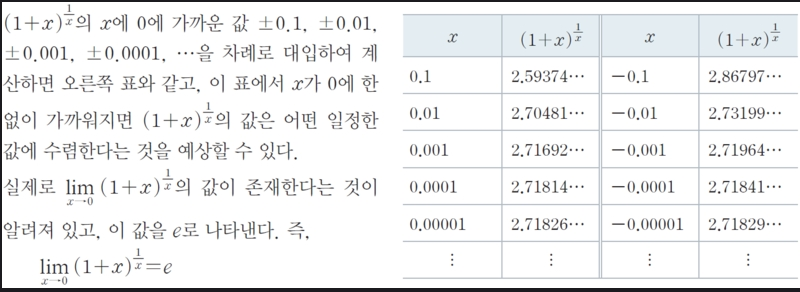

## 단순한 계층 구현하기 
* 계산 그래프의 곱셈 노드를 MulLayer, 덧셈 노드를 AddLayer라는 이름으로 구현합니다. 

### 곱셈 계층
* forward()와 backward()라는 공통의 메서드(인터페이스)를 갖도록 구현할 것입니다. 
* forward는 순전파를 backward는 역전파를 처리합니다. 

In [40]:
# 5.4.1 곱셈 계층
class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self, x, y):
        self.x = x
        self.y = y
        out = x * y
        return out

    def backward(self, dout):
        dx = dout * self.y
        dy = dout * self.x
        return dx, dy

* forward()에서는 x와 y를 인수로 받고 두 값을 곱해서 반환합니다. 
* 반면 backward()에서는 상류에서 넘어온 미분(dout)에 순전파 때의 값을 '서로 바꿔' 곱한 후 하류로 흘립니다. 

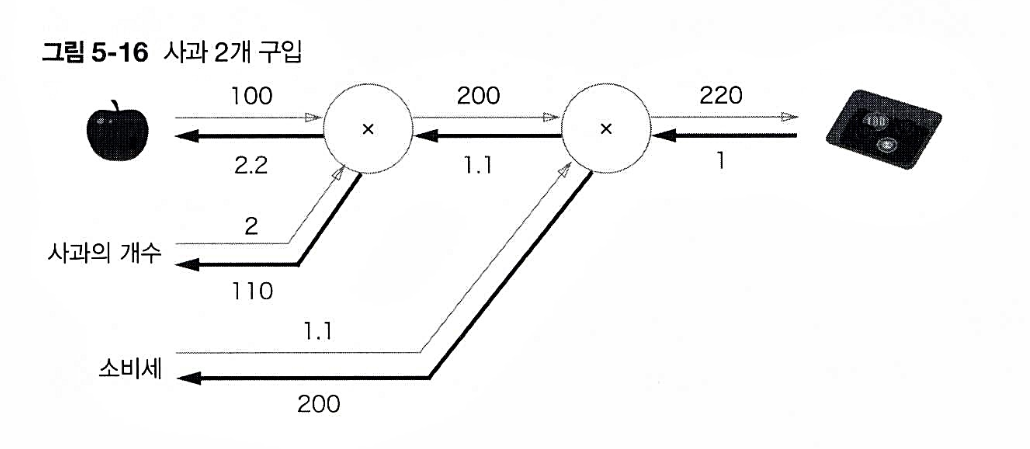

In [41]:
# 문제1의 예시
apple = 100
apple_num = 2
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

print(price)  # 220.0


220.00000000000003


#### 역전파

In [42]:
# 역전파
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax)  # 2.2 110.0 200

2.2 110.00000000000001 200


### 덧셈 계층

In [7]:
# 5.4.2 덧셈 계층
class AddLayer:
    def __init__(self):
        pass

    def forward(self, x, y):
        out = x + y
        return out

    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy

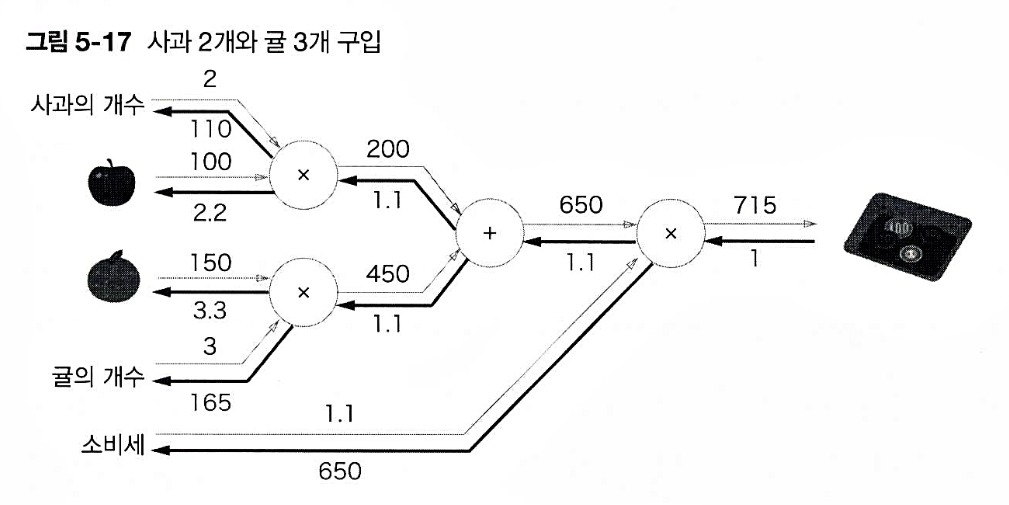

In [44]:
# 문제2의 예시
orange = 150
orange_num = 3

# 계층들
mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
orange_price = mul_orange_layer.forward(orange, orange_num)
all_price = add_apple_orange_layer.forward(apple_price, orange_price)
price = mul_tax_layer.forward(all_price, tax)

print(price)  # 715.0

715.0000000000001


#### 역전파

In [46]:
# 역전파
dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price)
dornage, dorange_num = mul_orange_layer.backward(dorange_price)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple_num, dapple, dornage, dorange_num, dtax)

110.00000000000001 2.2 3.3000000000000003 165.0 650


## 활성화 함수 계층 구현하기
* 우선은 활성화 함수인 ReLU와 Sigmoid 계층을 구현하겠습니다.

### ReLU 계층

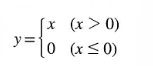

* 위 식에 대한 미분은 아래와 같습니다

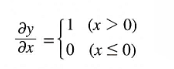

* 순전파 때의 입력인 x가 0보다 크면 역전파는 상류의 값을 그대로 하류로 흘립니다. 
* 반면 순전파 때 x가 0이하면 역전파 때는 하류로 신호를 보내지 않습니다. 

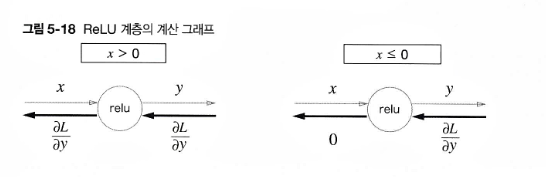

In [10]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [14]:
x = np.array([[1.0, -0.5], [-0.2, 3.0]])
print (x)
mask = (x <= 0)
print (mask)

[[ 1.  -0.5]
 [-0.2  3. ]]
[[False  True]
 [ True False]]


* 순전파 때의 입력 값이 0이하면 역전파 때의 값은 0이 돼야 합니다. 
* 그래서 역전파 때는 순전파 때 만들어둔 mask를 사용하여 mask의 원소의 값이 True인 곳에는 상류에서 전파된 dout를 0으로 설정합니다.

### Sigmoid 계층

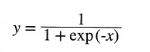

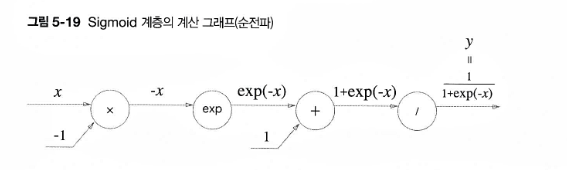

#### 역전파 

* $ y =  \frac{1}{x}$ 을 미분하면 다음 식이 됩니다. 

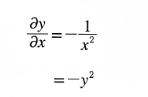

* 역전파 때는 상류의 예측값에 $-y^2 $을 곱해서 하류로 전달합니다.

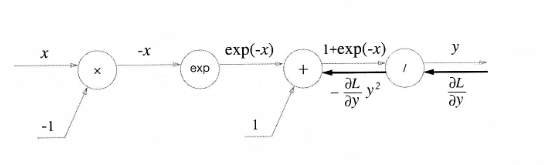

#### 2단계
* '+'노드는 상류의 값을 여과 없이 하류로 내보냅니다. 

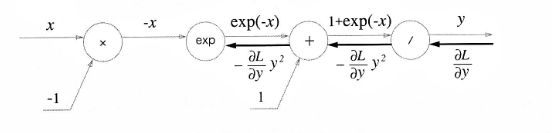

#### 3단계
* exp 노드는 y = exp(x) 연산을 수행하며, 그 미분은 다음과 같습니다. 

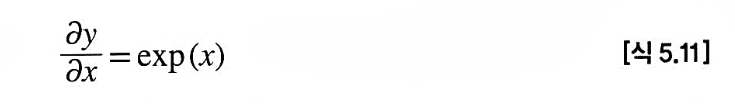

* 계산 그래프에서는 상류의 값에 순전파 때의 출력을 곱해 하류로 전달합니다. 

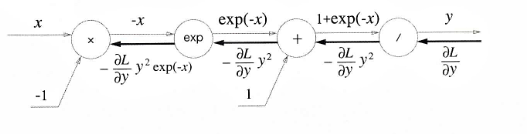

#### 4단계
* x 노드는 순전파 때의 값을 서로 바꿔 곱합니다. 이 예에서는 -1을 곱하면 됩겠습니다. 

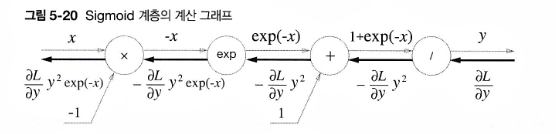

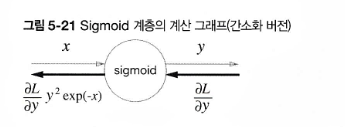

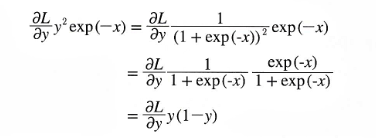

* sigmoid 계층의 역전파는 순전파의 출력(y)만으로 계산할 수 있습니다. 

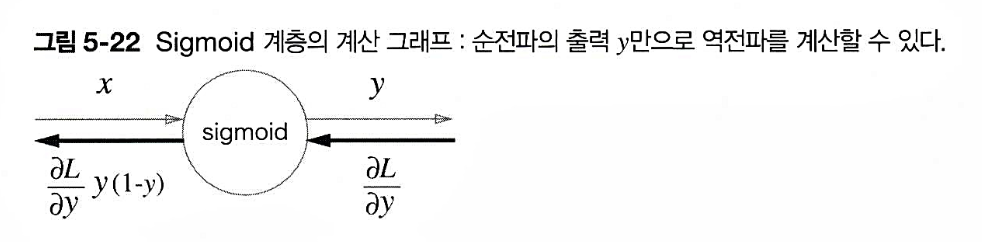

In [52]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out

        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

## Affine/Softmax 계층 구현하기
* 행렬의 내적을 기학학에서 affine transformation(어파인 변환)이라고 합니다. 

### Affine 계층
* 순전파에서는 가중치 신호의 총합을 계산하기 때문에 행렬의 내적(np.dot)을 사용했습니다.

In [1]:
import numpy as np

In [54]:
X = np.random.rand(2) #입력
W = np.random.rand(2,3) #가중치 
B = np.random.rand(3) # 편향 

print (X.shape)
print (W.shape)
print (B.shape)

Y = np.dot(X, W) + B

(2,)
(2, 3)
(3,)


In [3]:
Y

array([1.11155079, 1.23178844, 1.81360607])

* 위의 결과를 활성화 함수로 변환해서 다음 층으로 전파하는 것이 신경망 순전파의 흐름이었습니다. 
* 행렬의 내적 계산은 대응하는 차원의 원소 수를 일치시키는게 핵심입니다. 

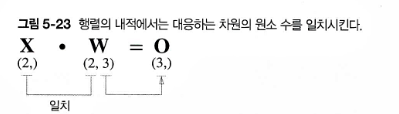

* 행렬의 내적은 기하학에서는 어파인 변환(affine transformation)이라고 합니다. 
* 이 책에서는 어파인 변환을 수행하는 처리를 Affine 계층이라는 이름으로 구현합니다.

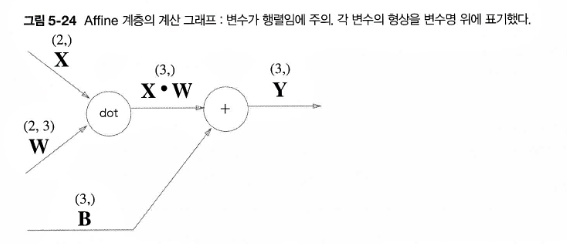

* 행렬을 사용한 역전파도 행렬의 원소마다 전개해보면 스칼라값을 사용한 지금까지의 계산 그래프와 같은 순서로 생각할 수있습니다.
* 실제로 전개해보면 다음 식이 이루어집니다. 

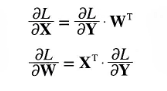

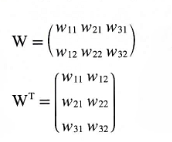

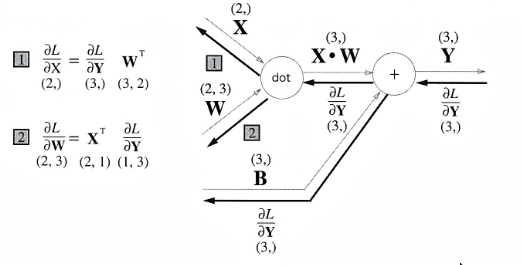

In [57]:
a = np.array([2,2])

In [61]:
a.shape

(2,)

In [62]:
a.T

array([2, 2])

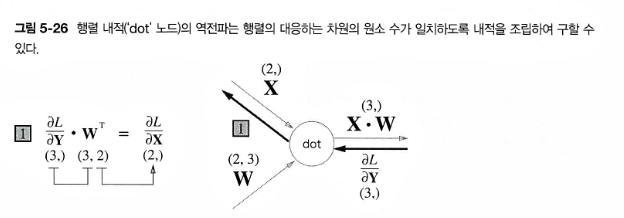

### 배치용 Affine 계층
* 데이터 N개를 묶어 순전파하는 경우, 즉 배치용 Affine 계층을 생각해보겠습니다. 

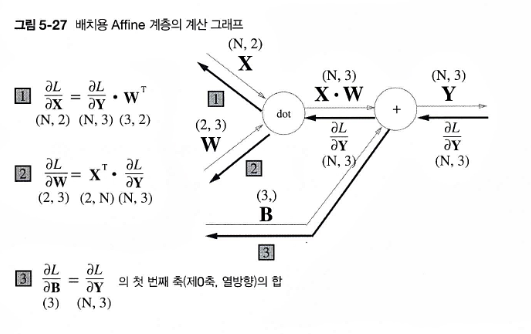

In [19]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        
        self.x = None
        self.original_x_shape = None
        # 가중치와 편향 매개변수의 미분
        self.dW = None
        self.db = None

    def forward(self, x):
        # 텐서 대응
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        # 편향의 역전파는 데이터에 대한 미분을 데이터마다 더해서 구합니다. 
        # np.sum()에서 0번째 축에 대해서 axis=0의 총합을 구하는 것입니다. 
        self.db = np.sum(dout, axis=0)
        
        return dx

### 순전파일때

In [20]:
X_dot_W = np.array([[0,0,0], [10, 10, 100]])
B = np.array([1,2,3])

In [21]:
X_dot_W

array([[  0,   0,   0],
       [ 10,  10, 100]])

In [22]:
X_dot_W + B

array([[  1,   2,   3],
       [ 11,  12, 103]])

### 역전파일때

In [23]:
dY = np.array([[1,2,3], [4,5,6]])
dY
np.sum(dY, axis=0)

array([5, 7, 9])

##  Softmax-with-loss 계층
* 소프트맥스 함수는 입력 값을 정규화하여 출력합니다. 

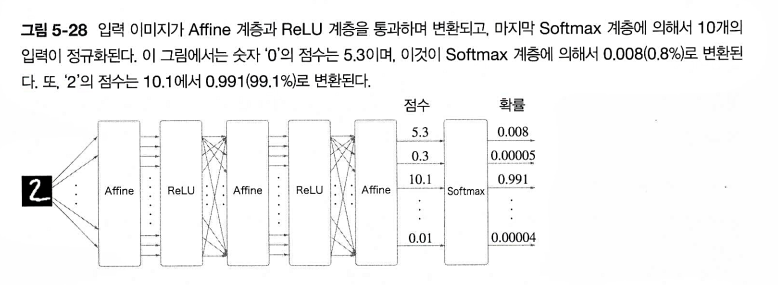

* 소프트맥스 계층을 구현할 텐데, 손실 함수인 교차 엔트로피 오차도 포함하여 Softmax-with-loass 계층이라는 이름을 구현합니다. 

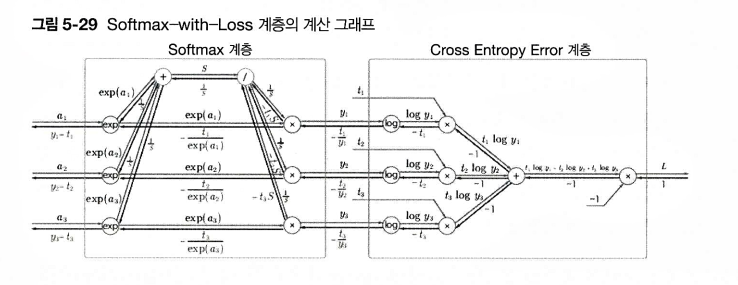

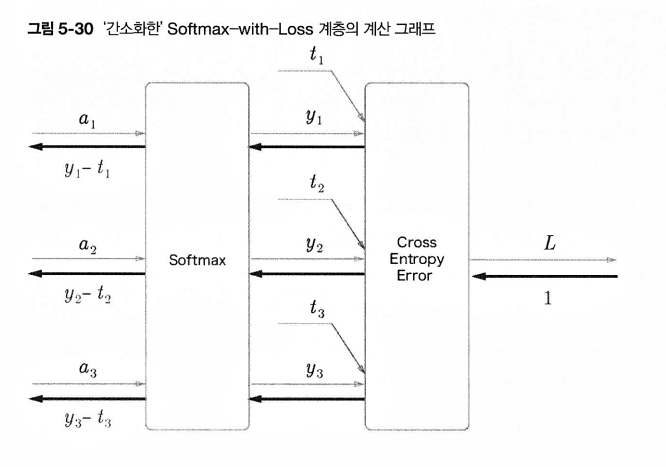

* 위 계산 그래프에서 소프트맥스 함수는 'Softmax' 계층으로, 교차 엔트로피 오차는 'Cross Entropy Error' 계층으로 표기했습니다. 
* 여기에서는 3클래스 분류를 가정하고 이전 계층에서 3개의 입력(점수)을 받습니다. 
* 그림과 같이 Softmax 계층은 입력 ($ a_1 $ , $ a_2 $, $ a_3 $)를 정규화하여 ($ y_1 $, $ y_2 $, $ y_3 $)를 출력합니다. 
* Cross Entropy Error 계층은 Softmax의 출력 ($ y_1 $, $ y_2 $, $ y_3 $)와 정답 레이블 ($ t_1 $, $ t_2 $, $ t_3 $)를 받고, 이들 데이터로부터 손실 L을 출력합니다.

----------
* 역전파에서는 ($ y_1 - t_1, y_2 - t_2, y_3 - t_3 $)라는 말끔한 결과를 내놓고 있습니다. 
* 해당 값은 Softmax 계층의 출력과 정답 레이블의 차분. 신경망의 역전파에서는 이 차이인 오차가 앞 계층에 전해지는 것입니다. 

* 정답 레이블 (0, 1, 0)일 때 softmax 계층이 (0.3, 0.2, 0.5)를 출력했다고 하면, 역전파는 (0.3, -0.8, -.5)라는 커다란 오차를 전파하게 됩니다. 
* 결과적으로 softmax 계층의 앞 계층들은 그 큰 오차로부터 큰 깨달음을 얻게 됩니다. 
----------
* 정답 레이블 (0, 1, 0)일 때 softmax 계층이 (0.01, 0.99, 0)를 출력했다고 하면, 역전파는 (0.01, -0.01, 0)이 됩니다.
* 앞 계층으로 전달된 오차가 작으므로 학습하는 정도도 작아집니다. 

In [24]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None # 손실함수
        self.y = None    # softmax의 출력
        self.t = None    # 정답 레이블(원-핫 인코딩 형태)
        
    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        
        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size: # 정답 레이블이 원-핫 인코딩 형태일 때
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size
        
        return dx


* 역전파 때는 전파하는 값을 배치의 수(batch_size)로 나눠서 데이터 1개당 오차를 앞 계층으로 전파하는 점에 주의하세요 

## 신경망 학습의 전체 그림

### 전체 
* 신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정을 '학습'이라 합니다. 신경망 학습은 다음과 같이 4단계로 수행합니다. 

### 1단계 - 미니배치 
* 훈련 데이터 중 일부를 무작위로 가져옵니다. 이렇게 선별한 데이터를 미니배치라 하며, 그 미니배치의 손실 함수 값을 줄이는 것을 목표로 한다. 

### 2단계 - 기울기 산출 
* 미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구합니다. 기울기는 손실 함수의 값을 가장 작게 하는 방향을 제시합니다. 
* 수치 미분은 구현은 쉽지만 아주 오래걸립니다. 오차역전파법을 사용하면 효율적으로 빠르게 구할 수 있습니다. 

### 3단계 - 매개변수 갱신 
* 가중치 매개변수를 기울기 방향으로 아주 조금식 갱신합니다. 

### 4단계 - 반복 
* 1 ~ 3단계를 반복합니다. 